In [3]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# unduh stop words (hanya perlu dijalankan sekali)
nltk.download('stopwords')

# Mengunduh dan memuat dataset langsung dari Kaggle
!pip install -q kagglehub

import kagglehub
from pathlib import Path

dataset_folder = Path(
    kagglehub.dataset_download(
        "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"
    )
)

# Menampilkan file yang berhasil diunduh
csv_files = list(dataset_folder.rglob("*.csv"))
print("File CSV ditemukan:", csv_files)

# Membaca file CSV pertama
df = pd.read_csv(csv_files[0])

print("Dataset berhasil dimuat")
print("Ukuran dataset:", df.shape)
df.head()

print("data awal (5 barisan pertama):")
print(df.head())
print("-" * 50)

#3. pembersihan dan pra-pemrosesan data
#konversi kolom sentiment
df['sentiment'] = df['sentiment'].map({'positive' : 1, 'negative' : 0})

#inisialisasi stop words dan stemmer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

#fungsi untuk membersihkan data
def clean_data(text):
  #menghapus tag HTML
  text = re.sub(r'<.*?>', '', text)

  #mengubah teks menjadi huruf kecil
  text = text.lower()

  #menghapus tanda baca dan karakter non-alfabet
  text = re.sub(r'[^a-z\s]', '', text) # Corrected regex

  #tokenisasi
  tokens = text.split()

  #menghapus stop words
  tokens = [word for word in tokens if word not in stop_words]

  #steming
  tokens = [stemmer.stem(word) for word in tokens]

  #menggabungkan kembali token menjadi string
  return ' '. join(tokens)

#menerapkan fungsi pembersihan ke kolom 'review'
df['clean_review'] = df['review'].apply(clean_data) # Added apply function

print("data setelah pembersihan:")
#tampilkan kolom review asli dan clean_review yang baru
print(df[['review', 'clean_review']].head())

#tampilkan ringkasan data yang sudah bersih
print("-" * 50)
print("informasi dataframe setelah dibersihkan")
df.info()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
File CSV ditemukan: [PosixPath('/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')]
Dataset berhasil dimuat
Ukuran dataset: (50000, 2)
data awal (5 barisan pertama):
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
--------------------------------------------------
data setelah pembersihan:
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ..

In [4]:
# Import library untuk pemodelan
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Menentukan fitur teks dan target
X = df["clean_review"]
y = df["sentiment"]

# Membagi teks menjadi data latih dan data uji sebelum TF-IDF
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF hanya mempelajari kosakata dari data latih
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train = tfidf_vectorizer.fit_transform(X_train_text)
X_test = tfidf_vectorizer.transform(X_test_text)

print("Jumlah data latih:", X_train.shape[0])
print("Jumlah data uji:", X_test.shape[0])
print("-" * 50)

# Melatih model Logistic Regression
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("Model berhasil dilatih")
print("-" * 50)

# Melakukan prediksi pada data uji
y_pred = model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)

print(f"Akurasi model: {accuracy:.4f}")
print("\nLaporan klasifikasi:")
print(classification_report(y_test, y_pred))

Jumlah data latih: 40000
Jumlah data uji: 10000
--------------------------------------------------
Model berhasil dilatih
--------------------------------------------------
Akurasi model: 0.8842

Laporan klasifikasi:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      5000
           1       0.88      0.89      0.89      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



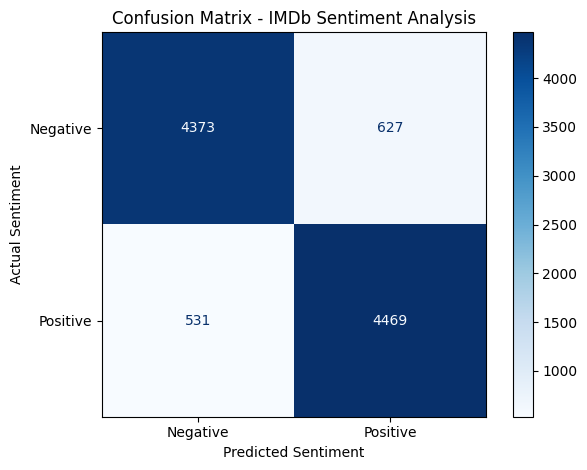

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Negative", "Positive"],
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - IMDb Sentiment Analysis")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

## Model Evaluation Summary

The Logistic Regression model achieved an accuracy of **88.42%** on 10,000 test reviews.

The confusion matrix shows:

- 4,373 negative reviews were classified correctly.
- 4,469 positive reviews were classified correctly.
- 627 negative reviews were incorrectly classified as positive.
- 531 positive reviews were incorrectly classified as negative.

Overall, the model demonstrates balanced performance across both sentiment classes, with precision, recall, and F1-scores ranging from 0.87 to 0.89.